<a href="https://colab.research.google.com/github/davidlealo/proyecto_sysrec_2026_1/blob/main/analisis_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib seaborn --quiet

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("tab10")


In [2]:
print("Subir todos los archivos benchmark_*.csv generados por el pipeline")
uploaded = files.upload()

dfs = []
for fname, content in uploaded.items():
    df = pd.read_csv(io.BytesIO(content))
    dfs.append(df)
    print(f"  {fname}: {len(df)} filas, hardware={df['hardware'].iloc[0]}")

raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal filas: {len(raw)}")
print(f"Hardwares: {sorted(raw['hardware'].unique())}")
print(f"Modelos: {sorted(raw['model'].unique())}")


Subir todos los archivos benchmark_*.csv generados por el pipeline


Saving benchmark_20260605_125033_T4_GPU.csv to benchmark_20260605_125033_T4_GPU.csv
Saving benchmark_20260605_133231_CPU(v5e-1 TPU).csv to benchmark_20260605_133231_CPU(v5e-1 TPU).csv
Saving benchmark_20260605_140127_CPU_HighRAM.csv to benchmark_20260605_140127_CPU_HighRAM.csv
Saving benchmark_20260605_142049_L4_GPU_HighRAM.csv to benchmark_20260605_142049_L4_GPU_HighRAM.csv
Saving benchmark_20260605_150741_A100_GPU_HighRAM.csv to benchmark_20260605_150741_A100_GPU_HighRAM.csv
  benchmark_20260605_125033_T4_GPU.csv: 10 filas, hardware=T4_GPU
  benchmark_20260605_133231_CPU(v5e-1 TPU).csv: 10 filas, hardware=CPU
  benchmark_20260605_140127_CPU_HighRAM.csv: 10 filas, hardware=CPU_HighRAM
  benchmark_20260605_142049_L4_GPU_HighRAM.csv: 10 filas, hardware=L4_GPU_HighRAM
  benchmark_20260605_150741_A100_GPU_HighRAM.csv: 10 filas, hardware=A100_GPU_HighRAM

Total filas: 50
Hardwares: ['A100_GPU_HighRAM', 'CPU', 'CPU_HighRAM', 'L4_GPU_HighRAM', 'T4_GPU']
Modelos: ['Caser', 'GRU4Rec', 'NextItN

In [ ]:
OUTLIER_MODEL = "Caser"
OUTLIER_HW = ["L4_GPU_HighRAM", "A100_GPU_HighRAM"]

mask_outlier = (raw["model"] == OUTLIER_MODEL) & (raw["hardware"].isin(OUTLIER_HW))
outliers = raw[mask_outlier].copy()
df = raw[~mask_outlier].copy()

print(f"Filas excluidas como outlier ({OUTLIER_MODEL} en {OUTLIER_HW}): {mask_outlier.sum()}")
print(f"Filas para análisis: {len(df)}")

hw_labels = {
    "CPU": "CPU",
    "T4_GPU": "T4",
    "L4_GPU_HighRAM": "L4",
    "A100_GPU_HighRAM": "A100",
}
df["hw"] = df["hardware"].map(hw_labels).fillna(df["hardware"])

SEQUENTIAL = ["SASRec", "GRU4Rec", "NextItNet", "Caser"]
BASELINES   = ["Pop", "Random"]

seq = df[df["model"].isin(SEQUENTIAL)].copy()
base = df[df["model"].isin(BASELINES)].copy()

print(f"\nFilas secuenciales: {len(seq)}, baselines: {len(base)}")


Filas excluidas como outlier (Caser en ['L4_GPU_HighRAM', 'A100_GPU_HighRAM']): 4
Filas para análisis: 46

Filas secuenciales: 36, baselines: 10


In [ ]:
resumen_hw = (
    df.groupby("hardware")
    .agg(
        runs=("model", "count"),
        co2_total_g=("co2_kg", lambda x: round(x.sum() * 1000, 3)),
        tiempo_total_min=("time_s", lambda x: round(x.sum() / 60, 1)),
        ndcg10_mean=("ndcg@10", lambda x: round(x.mean(), 4)),
    )
    .reset_index()
    .sort_values("co2_total_g")
)
resumen_hw["hw"] = resumen_hw["hardware"].map(hw_labels).fillna(resumen_hw["hardware"])
print("=== Resumen por hardware ===")
print(resumen_hw[["hw","runs","co2_total_g","tiempo_total_min","ndcg10_mean"]].to_string(index=False))


=== Resumen por hardware ===
         hw  runs  co2_total_g  tiempo_total_min  ndcg10_mean
       A100     8        0.335               0.4       0.0227
         L4     8        0.484               0.5       0.0227
CPU_HighRAM    10        1.392               3.4       0.0196
        CPU    10        2.701              18.7       0.0196
         T4    10        3.639               3.9       0.0202


In [ ]:
tabla_loss = (
    seq.groupby(["model", "loss"])
    .agg(
        ndcg10=("ndcg@10", "mean"),
        co2_g=("co2_kg", lambda x: x.mean() * 1000),
        time_s=("time_s", "mean"),
    )
    .round(4)
    .reset_index()
)
pivot_loss = tabla_loss.pivot(index="model", columns="loss", values=["ndcg10", "co2_g", "time_s"])
print("=== BPR vs CE por modelo ===")
print(pivot_loss.to_string())


=== BPR vs CE por modelo ===
           ndcg10           co2_g            time_s          
loss          BPR      CE     BPR      CE       BPR        CE
model                                                        
Caser      0.0098  0.0106  0.7061  0.7053  137.1390  137.1886
GRU4Rec    0.0103  0.0114  0.0729  0.0717   18.4171   18.1086
NextItNet  0.0099  0.0101  0.2205  0.2199   32.1900   32.0495
SASRec     0.0102  0.0108  0.1311  0.1321   27.9269   28.2517


In [ ]:
pivot_ndcg = seq.pivot_table(
    index="model", columns="hw", values="ndcg@10", aggfunc="mean"
).round(4)
print("=== NDCG@10 por modelo x hardware ===")
print(pivot_ndcg.to_string())

pivot_co2 = seq.pivot_table(
    index="model", columns="hw", values="co2_kg",
    aggfunc=lambda x: round(x.mean() * 1000, 4)
).round(4)
print("\n=== CO2 (g) por modelo x hardware ===")
print(pivot_co2.to_string())


=== NDCG@10 por modelo x hardware ===
hw           A100     CPU  CPU_HighRAM      L4      T4
model                                                 
Caser         NaN  0.0102       0.0102     NaN  0.0103
GRU4Rec    0.0108  0.0109       0.0109  0.0109  0.0107
NextItNet  0.0100  0.0100       0.0100  0.0099  0.0099
SASRec     0.0104  0.0107       0.0107  0.0105  0.0105

=== CO2 (g) por modelo x hardware ===
hw           A100     CPU  CPU_HighRAM      L4      T4
model                                                 
Caser         NaN  0.7163       0.2976     NaN  1.1031
GRU4Rec    0.0145  0.1621       0.1338  0.0216  0.0296
NextItNet  0.0855  0.2309       0.0905  0.1182  0.5759
SASRec     0.0566  0.2403       0.1718  0.0902  0.0991


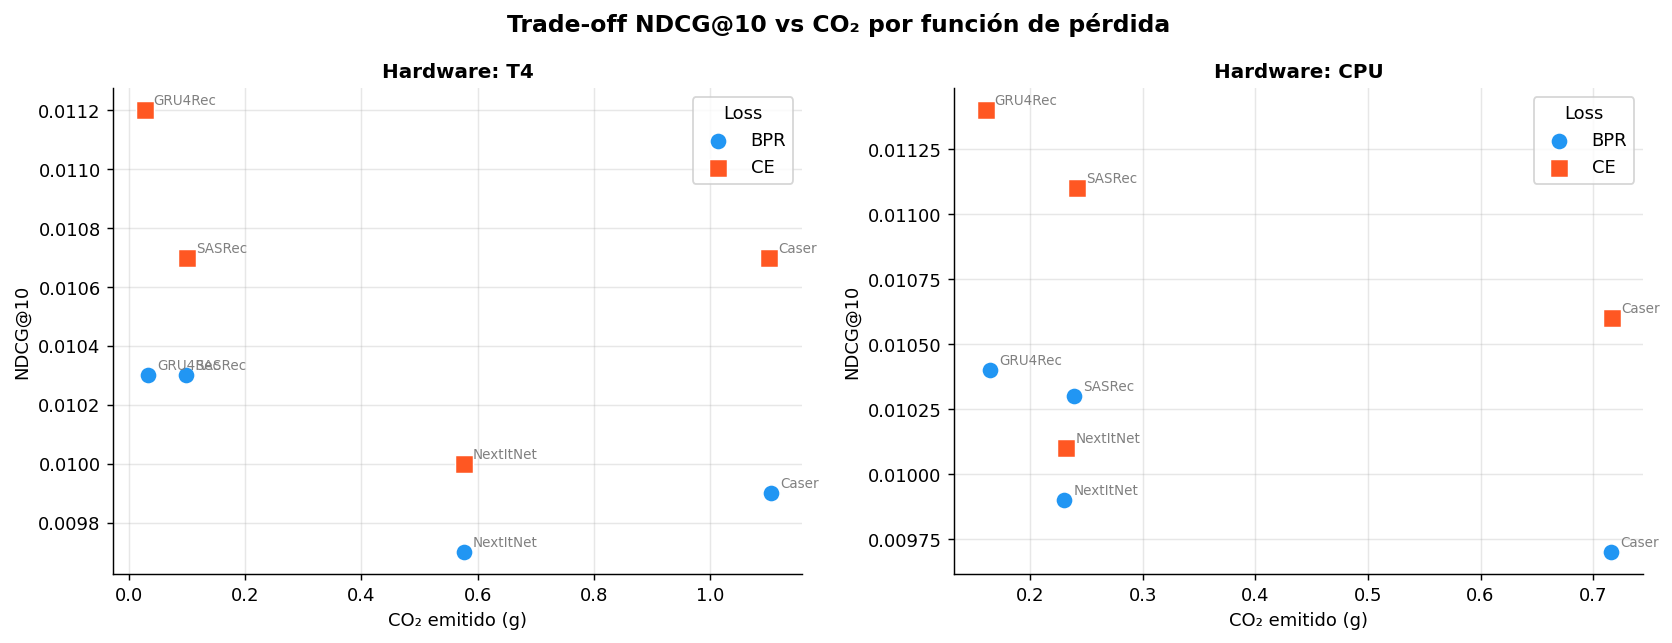

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"BPR": "#2196F3", "CE": "#FF5722"}
markers = {"BPR": "o", "CE": "s"}

for ax, hw_name in zip(axes, ["T4", "CPU"]):
    sub = seq[seq["hw"] == hw_name]
    for loss, grp in sub.groupby("loss"):
        ax.scatter(
            grp["co2_kg"] * 1000,
            grp["ndcg@10"],
            label=loss,
            color=colors[loss],
            marker=markers[loss],
            s=90, zorder=3, edgecolors="white", linewidth=0.8
        )
        for _, row in grp.iterrows():
            ax.annotate(
                row["model"],
                (row["co2_kg"] * 1000, row["ndcg@10"]),
                textcoords="offset points", xytext=(5, 3),
                fontsize=7.5, color="gray"
            )
    ax.set_xlabel("CO₂ emitido (g)", fontsize=10)
    ax.set_ylabel("NDCG@10", fontsize=10)
    ax.set_title(f"Hardware: {hw_name}", fontsize=11, fontweight="bold")
    ax.legend(title="Loss")
    ax.grid(axis="both", alpha=0.3)

fig.suptitle("Trade-off NDCG@10 vs CO₂ por función de pérdida", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_ndcg_co2.png", bbox_inches="tight")
plt.show()


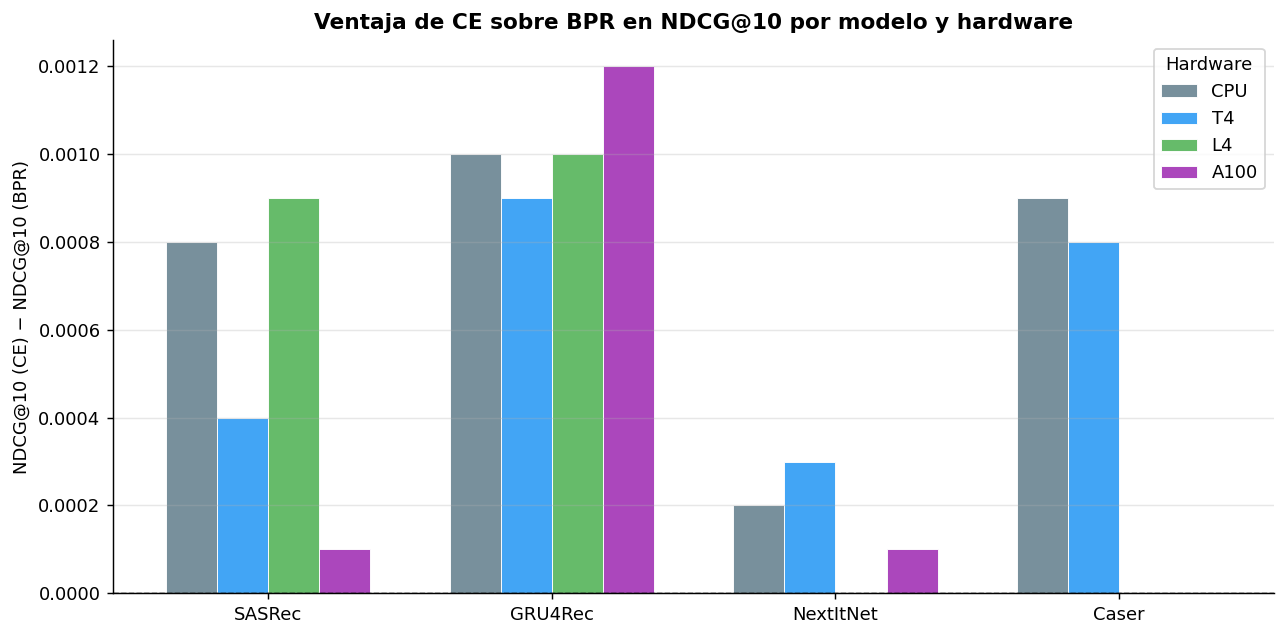

Valores positivos = CE supera a BPR. Barras ausentes = outlier excluido.


In [ ]:
diff = seq.pivot_table(index=["model","hw"], columns="loss", values="ndcg@10").reset_index()
diff["diff_CE_BPR"] = diff["CE"] - diff["BPR"]

hw_order = ["CPU", "T4", "L4", "A100"]
model_order = ["SASRec", "GRU4Rec", "NextItNet", "Caser"]

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.18
x = np.arange(len(model_order))
hw_colors = {"CPU": "#78909C", "T4": "#42A5F5", "L4": "#66BB6A", "A100": "#AB47BC"}

for i, hw in enumerate(hw_order):
    sub = diff[diff["hw"] == hw].set_index("model").reindex(model_order)
    bars = ax.bar(
        x + i * width - 1.5 * width,
        sub["diff_CE_BPR"].fillna(0),
        width=width,
        label=hw,
        color=hw_colors[hw],
        edgecolor="white",
        linewidth=0.5,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(model_order, fontsize=10)
ax.set_ylabel("NDCG@10 (CE) − NDCG@10 (BPR)", fontsize=10)
ax.set_title("Ventaja de CE sobre BPR en NDCG@10 por modelo y hardware", fontsize=12, fontweight="bold")
ax.legend(title="Hardware")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("bar_ce_vs_bpr.png", bbox_inches="tight")
plt.show()
print("Valores positivos = CE supera a BPR. Barras ausentes = outlier excluido.")


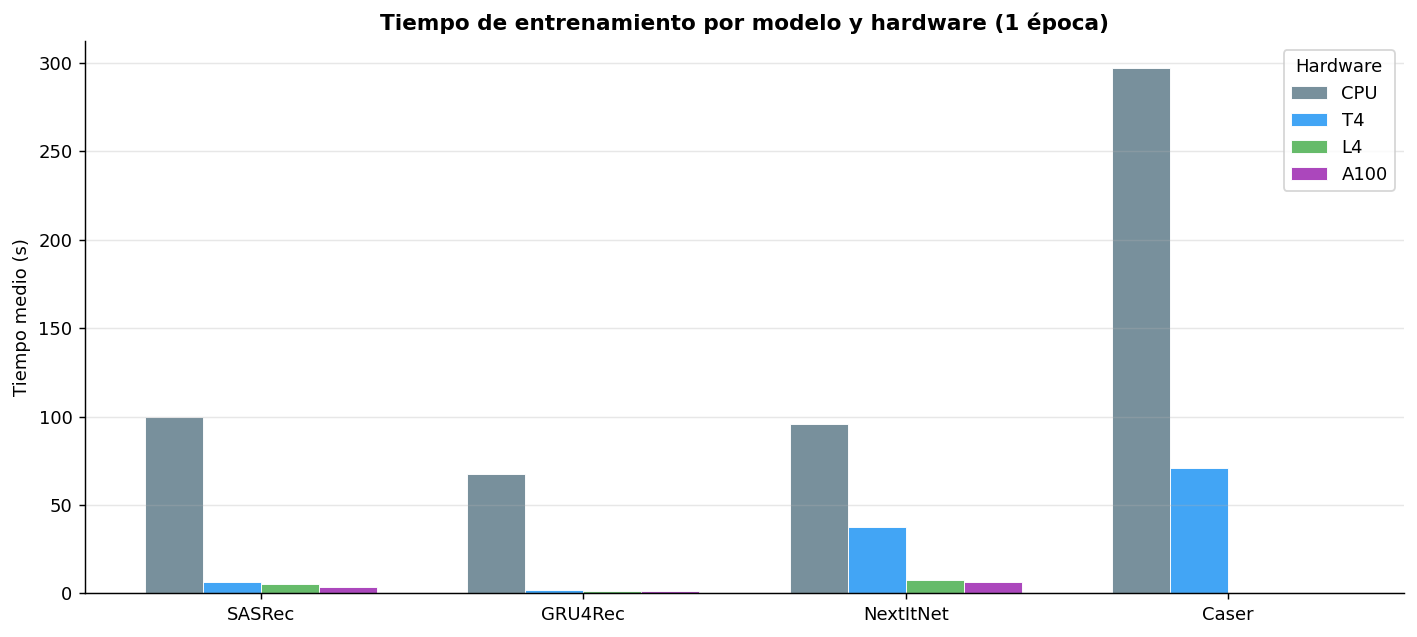

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
width = 0.18
x = np.arange(len(model_order))

for i, hw in enumerate(hw_order):
    sub = seq[seq["hw"] == hw].groupby("model")["time_s"].mean().reindex(model_order)
    ax.bar(
        x + i * width - 1.5 * width,
        sub.fillna(0),
        width=width,
        label=hw,
        color=hw_colors[hw],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(model_order, fontsize=10)
ax.set_ylabel("Tiempo medio (s)", fontsize=10)
ax.set_title("Tiempo de entrenamiento por modelo y hardware (1 época)", fontsize=12, fontweight="bold")
ax.legend(title="Hardware")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("bar_tiempo.png", bbox_inches="tight")
plt.show()


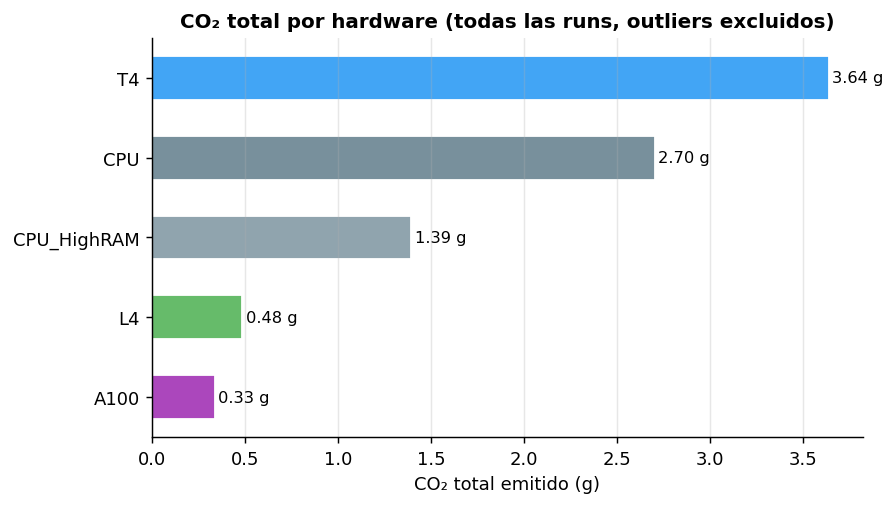

In [ ]:
co2_hw = (
    df.groupby("hw")["co2_kg"]
    .sum()
    .multiply(1000)
    .reset_index()
    .rename(columns={"co2_kg": "co2_g", "hw": "hardware"})
    .sort_values("co2_g")
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    co2_hw["hardware"],
    co2_hw["co2_g"],
    color=[hw_colors.get(h, "#90A4AE") for h in co2_hw["hardware"]],
    edgecolor="white",
    height=0.55,
)
for bar, val in zip(bars, co2_hw["co2_g"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f} g", va="center", fontsize=9)

ax.set_xlabel("CO₂ total emitido (g)", fontsize=10)
ax.set_title("CO₂ total por hardware (todas las runs, outliers excluidos)", fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("bar_co2_hw.png", bbox_inches="tight")
plt.show()


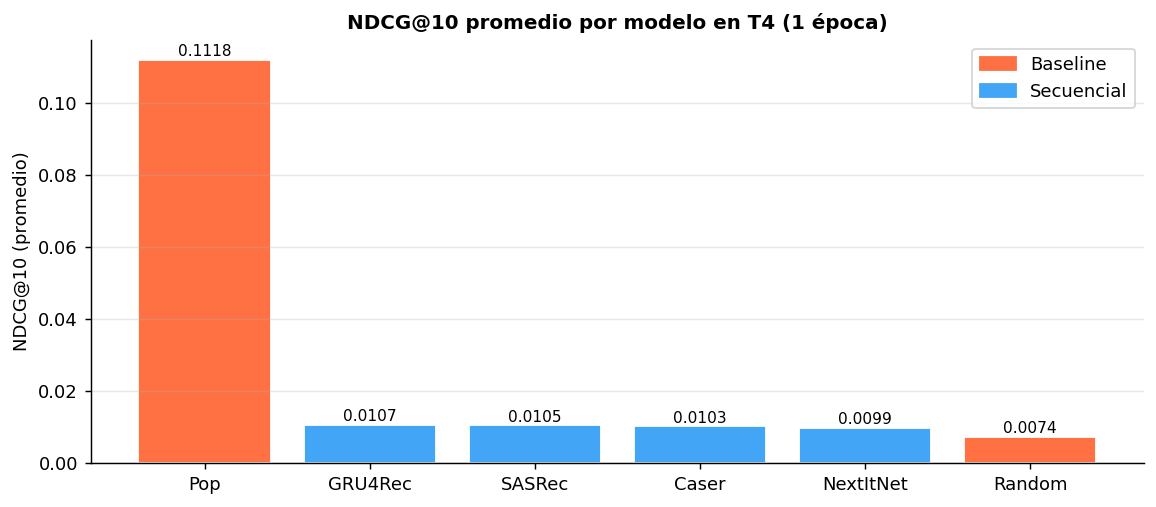

Nota: con 1 época los modelos secuenciales no convergen. Pop supera a todos por diseño.


In [ ]:
t4_all = df[df["hw"] == "T4"].copy()
t4_all["tipo"] = t4_all["model"].apply(
    lambda m: "Baseline" if m in BASELINES else "Secuencial"
)
t4_all["label"] = t4_all["model"] + ("\n(" + t4_all["loss"] + ")" if False else "")
t4_mean = t4_all.groupby(["model","tipo"])["ndcg@10"].mean().reset_index().sort_values("ndcg@10", ascending=False)

colors_tipo = {"Baseline": "#FF7043", "Secuencial": "#42A5F5"}
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    t4_mean["model"],
    t4_mean["ndcg@10"],
    color=[colors_tipo[t] for t in t4_mean["tipo"]],
    edgecolor="white",
)
for bar, val in zip(bars, t4_mean["ndcg@10"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f"{val:.4f}", ha="center", fontsize=8.5)

patch_b = mpatches.Patch(color="#FF7043", label="Baseline")
patch_s = mpatches.Patch(color="#42A5F5", label="Secuencial")
ax.legend(handles=[patch_b, patch_s])
ax.set_ylabel("NDCG@10 (promedio)", fontsize=10)
ax.set_title("NDCG@10 promedio por modelo en T4 (1 época)", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("bar_baselines_vs_seq.png", bbox_inches="tight")
plt.show()
print("Nota: con 1 época los modelos secuenciales no convergen. Pop supera a todos por diseño.")


In [ ]:
df.to_csv("resultados_limpios.csv", index=False)
raw.to_csv("todos_resultados_hw.csv", index=False)

with pd.ExcelWriter("tabla_comparativa_hardware.xlsx") as writer:
    resumen_hw.to_excel(writer, sheet_name="Resumen_por_HW", index=False)
    pivot_ndcg.to_excel(writer, sheet_name="Pivot_NDCG10")
    pivot_co2.to_excel(writer, sheet_name="Pivot_CO2")
    tabla_loss.to_excel(writer, sheet_name="BPR_vs_CE", index=False)
    outliers.to_excel(writer, sheet_name="Outliers_excluidos", index=False)

print("Archivos generados:")
for f in ["resultados_limpios.csv", "todos_resultados_hw.csv", "tabla_comparativa_hardware.xlsx"]:
    print(f"  {f}")

files.download("tabla_comparativa_hardware.xlsx")
files.download("resultados_limpios.csv")


Archivos generados:
  resultados_limpios.csv
  todos_resultados_hw.csv
  tabla_comparativa_hardware.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>